In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("advertising_sales_data.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


### Data Preprocessing

In [2]:
# Radio column has 2 null values, so I'm replacing them by mean of the column
df['Radio'] = df['Radio'].fillna(df['Radio'].mean())
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


## Ques 1.	What is the average amount spent on TV advertising in the dataset?


In [3]:
avg_TV = df['TV'].mean()
print(f"The average amount spent on TV advertising is {avg_TV}")

The average amount spent on TV advertising is 147.0425


## Ques 2.	What is the correlation between radio advertising expenditure and product sales?

In [4]:
radio_sales_corr = df['Radio'].corr(df['Sales'])
print(f"The correlation between radio advertising expenditure and product sales is {radio_sales_corr}")

The correlation between radio advertising expenditure and product sales is 0.3496507429302875


## Ques 3.	Which advertising medium has the highest impact on sales based on the dataset?

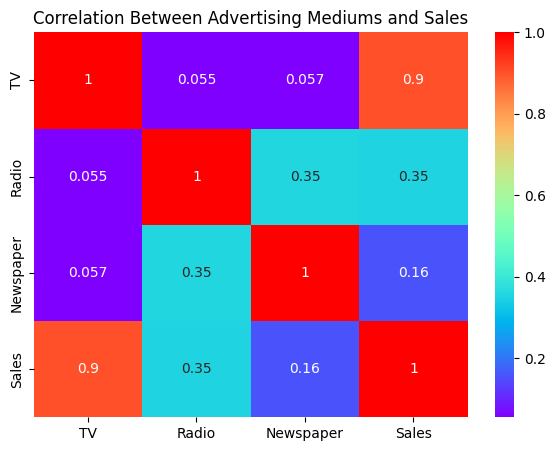

In [5]:
# Heatmap is used to demonstrate the impact of each medium on sales
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap="rainbow")
plt.title("Correlation Between Advertising Mediums and Sales")
plt.show()

The heatmap above tells that the **TV media** has the highest impact on the sales.

## Ques 4.	Plot a linear regression line that includes all variables (TV, Radio, Newspaper) to predict Sales, and visualize the model's predictions against the actual sales values.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [7]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# Predict Sales
y_pred = model.predict(X_test)

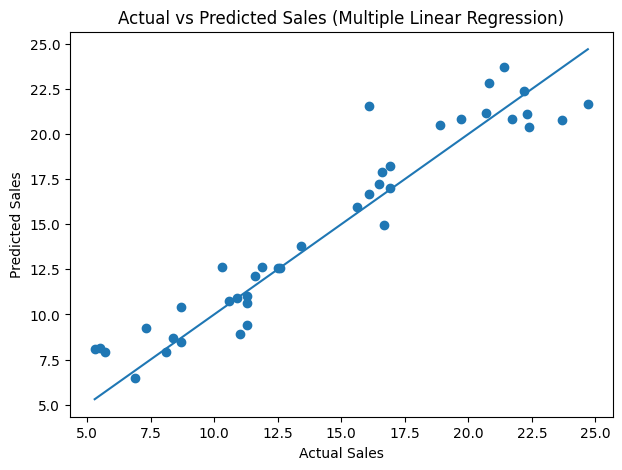

In [10]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Multiple Linear Regression)")

# Reference diagonal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

## Ques 5.	How would sales be predicted for a new set of advertising expenditures: $200 on TV, $40 on Radio, and $50 on Newspaper?

In [11]:
# We will use the pretrained model for this

new_data = pd.DataFrame([[200, 40, 50]], columns=["TV", "Radio", "Newspaper"])

predicted_sales = model.predict(new_data)
print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 19.871049209206635


## Ques 6.	How does the performance of the linear regression model change when the dataset is normalized?

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

### Without Normalization

In [13]:
r2_no_scale = r2_score(y_test, y_pred)
rmse_no_scale = np.sqrt(mean_squared_error(y_test, y_pred))

print("Without Normalization:")
print("R² Score:", r2_no_scale)
print("RMSE:", rmse_no_scale)

Without Normalization:
R² Score: 0.9059117026092904
RMSE: 1.7051193173793016


### With Normalization

In [14]:
# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model again on scaled data
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

# Predict
y_pred_scaled = model_scaled.predict(X_test_scaled)

# Metrics
r2_scaled = r2_score(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))

print("With Normalization:")
print("R² Score:", r2_scaled)
print("RMSE:", rmse_scaled)

With Normalization:
R² Score: 0.9059117026092903
RMSE: 1.7051193173793022


### Comparision

In [15]:
print("Comparison Summary:")
print("R² Difference:", abs(r2_no_scale - r2_scaled))
print("RMSE Difference:", abs(rmse_no_scale - rmse_scaled))

Comparison Summary:
R² Difference: 1.1102230246251565e-16
RMSE Difference: 6.661338147750939e-16


## Ques 7.	What is the impact on the sales prediction when only radio and newspaper advertising expenditures are used as predictors?

In [16]:
# Features: Only Radio and Newspaper
X_radio_news = df[["Radio", "Newspaper"]]
y_sales = df["Sales"]

# Train-test split
X_train_rn, X_test_rn, y_train_rn, y_test_rn = train_test_split(X_radio_news, y_sales, test_size=0.2, random_state=42)

# Train Linear Regression model
model_rn = LinearRegression()
model_rn.fit(X_train_rn, y_train_rn)

# Predict Sales
y_pred_rn = model_rn.predict(X_test_rn)

# Evaluate performance
r2_rn = r2_score(y_test_rn, y_pred_rn)
rmse_rn = np.sqrt(mean_squared_error(y_test_rn, y_pred_rn))

print("Model Performance Using Only Radio + Newspaper:")
print("R² Score:", round(r2_rn, 4))
print("RMSE:", round(rmse_rn, 4))

Model Performance Using Only Radio + Newspaper:
R² Score: 0.11
RMSE: 5.2443


Here, we observe that the model performance changes significantly when only
Radio and Newspaper advertising expenditures are used as predictors instead of all variables.

```
Previous Model (TV + Radio + Newspaper):
R² Score  = 0.90
RMSE      = 1.70
```

```
New Model (Radio + Newspaper only):
R² Score  = 0.11
RMSE      = 5.24
```

This shows that removing TV advertising greatly reduces the prediction accuracy.  
The R² value drops sharply, indicating that the model explains much less variance in sales,  
and the RMSE increases, meaning the prediction error becomes much larger.

Therefore, TV advertising is the most important predictor for sales in this dataset.